# Data Science & AI

**Group name:** The Turtur Squad

## all required installs:

pip install imbalanced-learn <br>
pip install geopandas <br>
pip install pandas <br>
pip install matplotlib <br>
pip install scikit-learn <br>
pip install numpy

**Import libraries**


In [3]:
# import 

import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import numpy as np
from imblearn.under_sampling import RandomUnderSampler

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## Load datasets

In [2]:
# CSV import

habitats_df = pd.read_csv('data/habitats_cbs_2022.csv')
turtur_df = pd.read_csv(
    'data/Streptopelia turtur.csv/Streptopelia turtur.csv',
    dtype={'Streptopelia turtur': 'object'}
)

# 2. Target cleaning & Presence (0 of 1)
turtur_df = turtur_df.rename(columns={'Streptopelia turtur': 'Streptopelia_turtur'})
target_numeric = pd.to_numeric(turtur_df['Streptopelia_turtur'], errors='coerce')
unknown_target_values = target_numeric.isna().sum()
turtur_df['Streptopelia_turtur'] = target_numeric.fillna(0)
turtur_df['presence'] = (turtur_df['Streptopelia_turtur'] > 0).astype(int)

# 3. Transforming the date and do the split
date_col = 'eventDate' 
turtur_df[date_col] = pd.to_datetime(turtur_df[date_col])
turtur_df['year'] = turtur_df[date_col].dt.year
turtur_df['month'] = turtur_df[date_col].dt.month
turtur_df['day'] = turtur_df[date_col].dt.day
turtur_df['day_of_week'] = turtur_df[date_col].dt.dayofweek
turtur_df = turtur_df.drop(columns=[date_col])

# Merge the datasets into 1 main dataset
# This will merge the dates and the habitats into merged_df
merged_df = pd.merge(
    turtur_df,
    habitats_df,
    on=['decimalLatitude', 'decimalLongitude'],
    how='inner'
)

## Data understanding

In [13]:
# CODE CELL: Initial EDA
# Loadtime: 31.1 sec
# Second improvement loadtime: ~2 sec
env_cols = ['agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland']

print('Dataset structure')
print(f'Turtle dove observations: {len(turtur_df):,} rows, 6 original columns')
print(f'Habitat data: {len(habitats_df):,} rows, {habitats_df.shape[1]} columns')
print(f'Merged data: {len(merged_df):,} rows')

print('\nMissing values')
print('Turtle dove data:')
print(turtur_df.drop(columns=['presence']).isna().sum())
print(f'Non-numeric target values converted to 0: {unknown_target_values}')
print('\nHabitat data:')
print(habitats_df.isna().sum())

print('\nTarget distribution after merging')
class_distribution = merged_df['presence'].value_counts().sort_index()
class_summary = pd.DataFrame({
    'label': ['absence', 'presence'],
    'count': class_distribution.values,
    'percent': (class_distribution.values / class_distribution.sum() * 100).round(4)
})
print(class_summary.to_string(index=False))

print('\nPresence rate by main habitat')
presence_by_habitat = merged_df.groupby('main_habitat')['presence'].agg(['count', 'sum', 'mean'])
presence_by_habitat = presence_by_habitat.rename(columns={'count': 'observations', 'sum': 'presences', 'mean': 'presence_rate'})
presence_by_habitat['presence_rate_percent'] = (presence_by_habitat['presence_rate'] * 100).round(4)
print(presence_by_habitat.sort_values('presence_rate_percent', ascending=False)[['observations', 'presences', 'presence_rate_percent']].to_string())

print('\nEnvironmental variable skewness')
print(habitats_df[env_cols].skew().sort_values(ascending=False).round(2).to_string())

Dataset structure
Turtle dove observations: 12,558,786 rows, 6 original columns
Habitat data: 2,179 rows, 11 columns
Merged data: 12,558,756 rows

Missing values
Turtle dove data:
decimalLatitude              0
decimalLongitude             0
total_observations           5
speciesgroup_observations    0
Streptopelia_turtur          0
year                         0
month                        0
day                          0
day_of_week                  0
dtype: int64
Non-numeric target values converted to 0: 4

Habitat data:
decimalLongitude    0
decimalLatitude     0
agricultural        0
built               0
coast               0
forest              0
other               0
sand/heather        0
water               0
wetland             0
main_habitat        0
dtype: int64

Target distribution after merging
   label    count  percent
 absence 12543710  99.8802
presence    15046   0.1198

Presence rate by main habitat
              observations  presences  presence_rate_percent
main_h

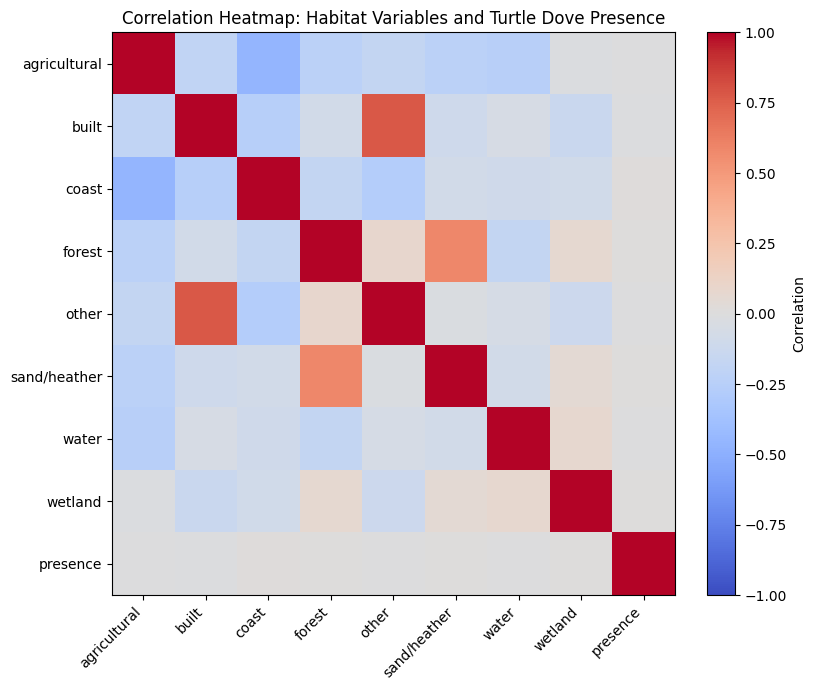

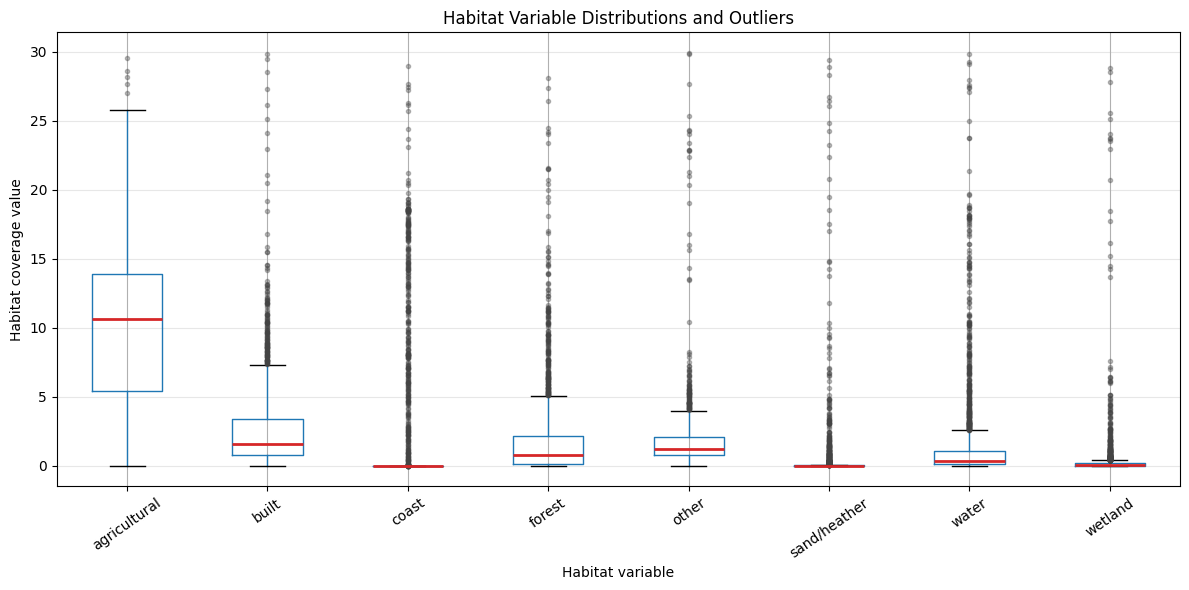

IQR outlier summary for habitat variables
    variable    q1  median     q3  lower_bound  upper_bound  outlier_count  outlier_percent
sand/heather 0.000   0.000  0.027       -0.040        0.068            424            19.46
       coast 0.000   0.000  0.000        0.000        0.000            366            16.80
     wetland 0.000   0.019  0.158       -0.237        0.395            311            14.27
       water 0.103   0.318  1.096       -1.387        2.586            286            13.13
      forest 0.153   0.735  2.124       -2.803        5.080            192             8.81
       built 0.780   1.584  3.391       -3.137        7.308            143             6.56
       other 0.735   1.213  2.042       -1.225        4.003            111             5.09
agricultural 5.394  10.624 13.883       -7.339       26.616              5             0.23


In [7]:
# CODE CELL: Generate visualizations
# Correlation heatmap and boxplots for habitat variables
# loadtime: 25.4 sec
# Improved loadtime: 3.5 - 5.1 sec

env_cols = ['agricultural', 'built', 'coast', 'forest', 'other', 'sand/heather', 'water', 'wetland']

try:
    correlation_source = merged_df
except NameError:
    turtur_df = pd.read_csv(
        'data/Streptopelia turtur.csv/Streptopelia turtur.csv',
        dtype={'Streptopelia turtur': 'object'}
    )
    turtur_df = turtur_df.rename(columns={'Streptopelia turtur': 'Streptopelia_turtur'})
    turtur_df['Streptopelia_turtur'] = pd.to_numeric(turtur_df['Streptopelia_turtur'], errors='coerce').fillna(0)
    turtur_df['presence'] = (turtur_df['Streptopelia_turtur'] > 0).astype(int)
    correlation_source = pd.merge(
        turtur_df,
        habitats_df,
        on=['decimalLatitude', 'decimalLongitude'],
        how='inner'
    )

corr_matrix = correlation_source[env_cols + ['presence']].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(9, 7))
heatmap = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap: Habitat Variables and Turtle Dove Presence')
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.index)
fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04, label='Correlation')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 6))
habitats_df[env_cols].boxplot(
    ax=ax,
    showfliers=True,
    medianprops={'color': '#d62728', 'linewidth': 2},
    flierprops={'marker': 'o', 'markersize': 3, 'markerfacecolor': '#444444', 'markeredgecolor': '#444444', 'alpha': 0.35}
)
ax.set_title('Habitat Variable Distributions and Outliers')
ax.set_xlabel('Habitat variable')
ax.set_ylabel('Habitat coverage value')
ax.tick_params(axis='x', rotation=35)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

outlier_rows = []
for col in env_cols:
    values = habitats_df[col]
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outlier_count = ((values < lower_bound) | (values > upper_bound)).sum()
    outlier_rows.append({
        'variable': col,
        'q1': round(q1, 3),
        'median': round(values.median(), 3),
        'q3': round(q3, 3),
        'lower_bound': round(lower_bound, 3),
        'upper_bound': round(upper_bound, 3),
        'outlier_count': int(outlier_count),
        'outlier_percent': round(outlier_count / len(values) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values('outlier_count', ascending=False)
print('IQR outlier summary for habitat variables')
print(outlier_summary.to_string(index=False))


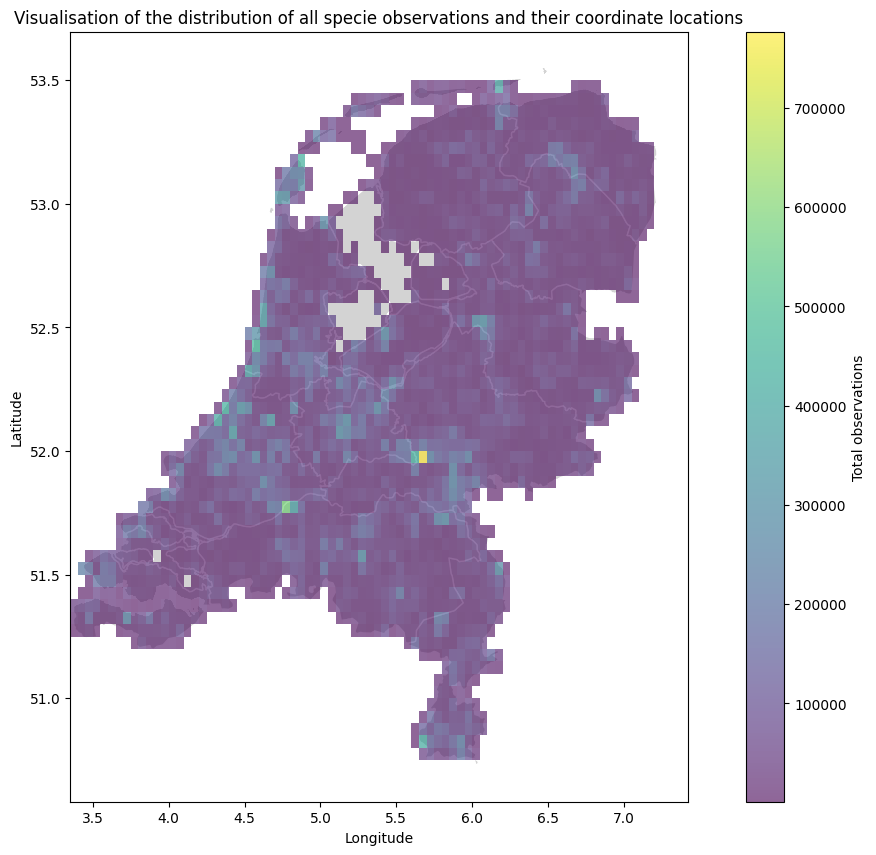

In [7]:
nl_layer = gpd.read_file("data/gadm41_NLD.gpkg", layer="ADM_ADM_1")
def show_distribution_map(df_map, nl):
    fig, ax = plt.subplots(figsize=(15, 10))
    nl.plot(ax=ax, color='lightgray', edgecolor='white')

    bin_w = 0.05
    x_bins = np.arange(df_map['decimalLongitude'].min(), df_map['decimalLongitude'].max() + bin_w, bin_w)
    y_bins = np.arange(df_map['decimalLatitude'].min(), df_map['decimalLatitude'].max() + bin_w, bin_w)

    heatmap, xedges, yedges = np.histogram2d(
        df_map['decimalLongitude'],
        df_map['decimalLatitude'],
        bins=[x_bins, y_bins],
        weights=df_map['total_observations']
    )

    heatmap = np.where(heatmap == 0, np.nan, heatmap)
    mesh = ax.pcolormesh(
        xedges,
        yedges,
        heatmap.T,
        alpha=0.6,
        cmap='viridis'
    )
    fig.colorbar(mesh, ax=ax, label='Total observations')
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title("Visualisation of the distribution of all specie observations and their coordinate locations")
    plt.show()

show_distribution_map(merged_df, nl_layer)

## Benchmark model

In [14]:
# Benchmark Model

# Note: turtur_df, habitats_df, and merged_df are already loaded and processed.
# We reuse them here to display previews and calculate the baseline performance.

# Preview datasets
print("Turtle dove data preview:")
print(turtur_df.head())

print("\nHabitat data preview:")
print(habitats_df.head())

# Check class distribution
print("\nClass Distribution:")
print(merged_df['presence'].value_counts())

# Find majority class
majority_class = merged_df['presence'].mode()[0]

print(f"\nMajority Class: {majority_class}")

# Calculate benchmark accuracy
benchmark_accuracy = (
    merged_df['presence'] == majority_class
).mean()

print(f"\nBenchmark Accuracy: {benchmark_accuracy:.2%}")

Turtle dove data preview:
   decimalLatitude  decimalLongitude  total_observations  \
0            50.75              5.65                 0.0   
1            50.75              5.65                26.0   
2            50.75              5.65                 3.0   
3            50.75              5.65                 0.0   
4            50.75              5.65                 0.0   

   speciesgroup_observations  Streptopelia_turtur  presence  year  month  day  \
0                          0                  0.0         0  2010      1    1   
1                         26                  0.0         0  2010      1    2   
2                          3                  0.0         0  2010      1    3   
3                          0                  0.0         0  2010      1    4   
4                          0                  0.0         0  2010      1    5   

   day_of_week  
0            4  
1            5  
2            6  
3            0  
4            1  

Habitat data preview:
 

## Data preperation

In [16]:
# Define X and y from the merged dataset
X = merged_df.drop(columns=['Streptopelia_turtur', 'presence'])
y = merged_df['presence']

# Convert categorical text columns (like 'main_habitat') into numerical dummy columns (One-Hot Encoding)
# This transforms 'coast', 'forest' etc. into separate columns with 1s and 0s so the model can read them
X = pd.get_dummies(X, columns=['main_habitat'], dtype=int)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Resample the training data
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

# Save the downsampled training data to CSV (including the new habitat columns)
train_resampled_df = pd.DataFrame(X_train_resampled, columns=X.columns)
train_resampled_df['presence'] = y_train_resampled
train_resampled_df.to_csv('data/downSampBirdData_train.csv', index=False)

print(f"The downsampel trainingsset has {len(train_resampled_df)} rows.")

The downsampel trainingsset has 24074 rows.


## Modeling

In [18]:
# Baseline RF model without any hyperparameter tuning or whatsoever

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9580527854660811
[[2403581  105162]
 [    199    2810]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98   2508743
           1       0.03      0.93      0.05      3009

    accuracy                           0.96   2511752
   macro avg       0.51      0.95      0.51   2511752
weighted avg       1.00      0.96      0.98   2511752

